#### Student informations (Max. 2 students) should be written in this cell (Student ID, Student Name).
Student ID: 150220044
Student Name: Ahmed Said Gülşen

In [9]:
%load_ext autoreload
%autoreload 2

# HOMEWORK 3 : LINEAR AND NON-LINEAR CLASSIFICATION WITH SUPPORT VECTOR MACHINES

In this homework, you are assigned to train Support Vector Machines models for non-linear classification problems. This homework will help you to get familiar with **scikit-learn (sklearn)** machine learning libray. You may install sklearn in your conda environments by calling 


```bash
conda install scikit-learn
```

Your homework includes 3 problems in total. Please read this notebook carefully to provide all required solutions to the problems.

First, we will start by reviewing Support Vector Machines. 

## Support Vector Machines (SVM)

Suppose we have a two-class classification training dataset of $P$ input/output pairs $\{(\mathbf{x}_p, y_p)\}^{P}_{p=1}$ with the labels $y_p \in \{-1, +1\}$. Given a training set, SVM tries to find a decision boundary that maximizes the geometric margin, which reflects a confident set of predictions on the training set and a good fit to the training data. SVM results in a classifier that separates different class examples with a geometric margin, which is also called "gap". 

Let's say we have a linearly separable dataset, primal optimization problem for finding the maximum margin classifier is:

<div style="text-align:center">

$ \min_{\gamma, \textbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 $
</div>

<div style="text-align:center">

$ s.t. y_p(\textbf{w}^T \textbf{x}_p + b) \geq 1,   \quad  p = 1, ... , P $

</div>

The above is an optimization problem with a convex quadratic objectuve and only linear constraints. Its solution gives us the **optimal margin classifier** . This optimization problem can be solved using Quadratic Programming. 

By employing **Lagrange Duality**, optimal margin classifiers can work efficiently in very high dimensional spaces. Finally, SVM classification solves the following problem:

<div style="text-align:center">

$ \min_{\textbf{w}, b} \|\mathbf{w}\|^2 + C \sum_{p=1}^P \xi_p $
</div>

<div style="text-align:center">

$ s.t. y_p(\textbf{w}^T\textbf{x}_p + b) \geq 1 - \xi_p,   \quad  p = 1, ... , P $

</div>


<div style="text-align:center">

$ \xi_p \geq 0 , \quad  p = 1, ... , P $

</div>

After solving, SVM predicts "+1" if $(\textbf{w}^T\textbf{x}_p + b) \geq 0$ and "-1" otherwise. The decision boundary is given by $ (\textbf{w}^T\textbf{x}_p + b) = 0$ .  


### Kernels

Linearly non-separable features often become linearly separable after they are mapped to a high dimensional feature space. We do not need to compute the feature mappings $\phi (\textbf{x}_p)$ and it saves a large amount of computations in practice. We only need to work with their kernels. SVM kernels provide a powerful framework for capturing complex relationships in the data and building robust classification models. There are several commonly used kernels: **linear kernel, polynomial kernel, and Radial Basis Function kernel**. 

### The RBF Kernel

This kernel has the formula:

$K(\textbf{x}_i, \textbf{x}_j) = \phi(\textbf{x}_i)^T \phi(\textbf{x}_j)$

$= exp (-\gamma \|\textbf{x}_i - \textbf{x}_j\|^2 ), \quad \gamma > 0 $

This is the same as **Gaussian** kernel, except that term $\frac{1}{2 \sigma ^2}$ in the Gaussian kernel has been replaced by $\gamma$. It provides a reasnable measure of $\textbf{x}_i$ and $\textbf{x}_j$'s similarity, it is close to 1 when $\textbf{x}_i$ and $\textbf{x}_j$ are close, and near 0 when they are far apart. 

In this assignment you are expected to train SVM models with **scikit-learn(sklearn)**. Sklearn is a popular machine learning library in Python that provides a user-friendly interface for building SVM models. Here's a basic outline of using SVM in scikit-learn:

In [10]:
# Importing the SVM class:
from sklearn.svm import SVC

Support Vector Classification (SVC) is a variant of Support Vector Machines (SVM) primarily used for classification tasks. It works by finding the optimal hyperplane that separates the classes in the feature space while maximizing the margin between them. Sklearn offers various kernels such as linear, polynomial, RBF, and sigmoid kernels.

Let's say we have the following toy training set **x_train** and **y_train**:

In [11]:
# Toy example data for two classes
x_train = [[-0.2, 0.5],
           [-0.3, 0.6],
           [-0.5, 0.4],
           [-0.6, 0.1],
           [-0.5, -0.2],
           [-0.3, -0.2],
           [-0.2, -0.05],
           [0.3, -0.4],
           [0.5, -0.3],
           [0.4, -0.6],
           [0.2, -0.7],
           [0.1, -0.5]]

y_train = [1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1]

Let's initialize the SVC:

In [12]:
#Initializing the SVM Classifier
svm_classifier = SVC(kernel='linear')

In [13]:
# Fit the model to the training data
svm_classifier.fit(x_train, y_train)

# Make predictions
# y_pred = svm_classifier.predict(X_test)
# Note: We're making predictions on the training data here for simplicity
y_pred = svm_classifier.predict(x_train)

# Calculate accuracy

from sklearn.metrics import accuracy_score
# accuracy = accuracy_score(y_test, y_pred)
# Note: We don't have test labels y_test in this example, so we're calculating accuracy on training data
accuracy = accuracy_score(y_train, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


You are allowed to use various functions and classes sklearn provides for performance calculations.

## Q1) Non-linear Decision Boundary with RBF in 2-classes 

In this question we will see how an RBF kernel can choose a non-linear decision boundary. You have been provided with "data.npy". This data is normalized, so you do not need any preprocessing. Please fit your support vector classifier by using sklearn library, and plot the examples and the decision boundary. Train an SVM model with RBF kernel with $\gamma = 100$. Once you have the model trained, please visualize the decision boundary. 

Run the following cell to load the data:

In [14]:
import numpy as np

def read_data_from_npy(filename):
    """
    Reads numpy arrays x and y from .npy file.
    
    Parameters:
        filename (str): Name of the .npy file to read.
    
    Returns:
        numpy.ndarray, numpy.ndarray: Input features array (x) and target labels array (y).
    """
    data = np.load(filename, allow_pickle=True)
    x = data.item().get('x')
    y = data.item().get('y')
    print(f"Data loaded from {filename}.")
    return x, y

# Read data from .npy file
x_loaded, y_loaded = read_data_from_npy('data.npy')

Data loaded from data.npy.


Let's visualize the data: 

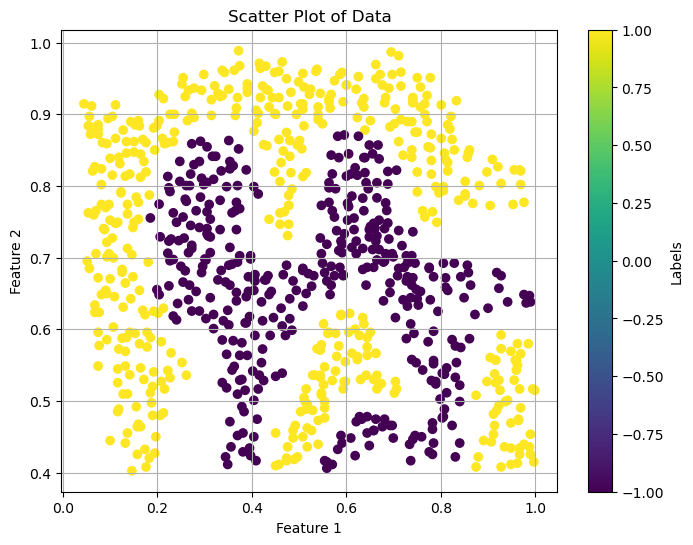

In [15]:
import matplotlib.pyplot as plt

def plot_scatter(x, y):
    """
    Plots the data as a scatter plot.
    
    Parameters:
        x (numpy.ndarray): Input features array.
        y (numpy.ndarray): Target labels array.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Scatter Plot of Data')
    plt.colorbar(label='Labels')
    plt.grid(True)
    plt.show()

# Example usage:
plot_scatter(x_loaded, y_loaded)

In this question, you are expected to use a Support Vector Classifier from sklearn.

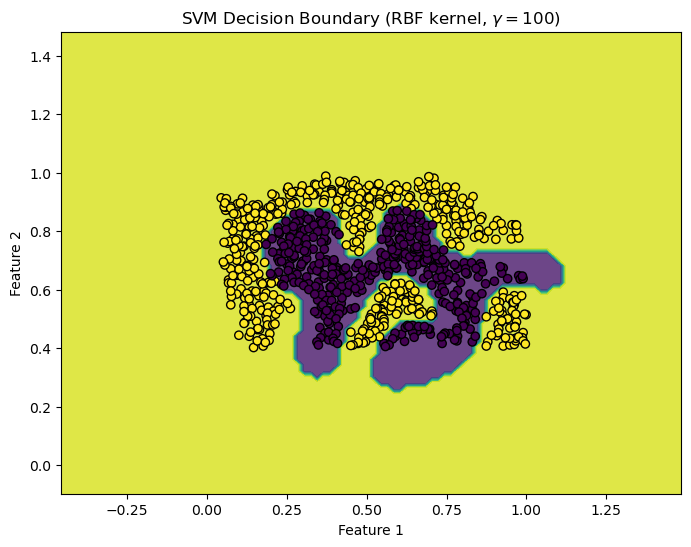

In [16]:
##############################################################################
# TODO: -Fit SVC do the dataset by using RBF kernel in sklearn.              #
# -Set gamma = 100.                                                          #
# -Visualize the decision boundary                                           #
##############################################################################

# 1. Initialize the SVM Classifier with RBF kernel and gamma = 100
svm_rbf = SVC(kernel='rbf', gamma=100)

# 2. Fit the model to our loaded dataset
svm_rbf.fit(x_loaded, y_loaded)

# 3. Visualization function for the decision boundary
def plot_decision_boundary(model, X, y):
    # Set min and max values for the axes
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # Generate a grid of points with distance h between them
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict the function value for the whole grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the contour and training examples
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='viridis')
    plt.title("SVM Decision Boundary (RBF kernel, $\gamma=100$)")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Call the visualization function
plot_decision_boundary(svm_rbf, x_loaded, y_loaded)


##############################################################################
#                             END OF YOUR CODE                               #
##############################################################################

## Q2) Multi-Class Non-linear Classification with Support Vectors

In this question, you are assigned to implement a non-linear SVC for the toy dataset "Iris". Split the data into training and test sets (%30-%70 ratio). You may use **train_test_split** from **sklearn.model_selection**. Normalize the dataset. After that, you are assigned to call:

1) Linear,
2) Polynomial,
3) Gaussian RBF,

kernels on your classifiers.

You should tune each model using **cross validation** (you may use sklearn) and report the best hyperparameters $\gamma$ and $C$ you've found. You will use these hyperparameters for testing later. Once you have selected the best hyperparameters for each kernel, Report the following (on the **test** set):

- Confusion matrix, Recall, Precision, and F1 Score.

**Note**: Suggested ranges for searching C and $\gamma$ parameters:

- C (Regularization parameter): [0.1, 1, 10, 100, 1000]. It's common to use a logarithmic scale for searching C values.

- $\gamma$ (Kernel coefficient for 'rbf' and 'poly' kernels): [0.001, 0.01, 0.1, 1, 10, 100] Since the dataset will be scaled, you can explore a broader range of gamma values.

For this question, first, we will call **load_iris** from sklearn. 

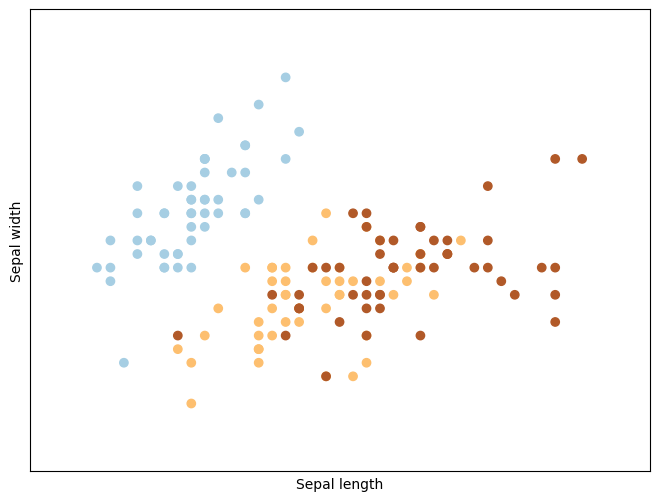

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets

# Import the Iris dataset
iris = datasets.load_iris()

# Extract features and target variable
X = iris.data[:, :2]  # We only take the first two features.
Y = iris.target

# Define the minimum and maximum values for plotting
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5

# Create a new figure
plt.figure(2, figsize=(8, 6))
plt.clf()

# Plot the training points
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

# Set limits for the plot
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

# Remove ticks
plt.xticks(())
plt.yticks(())

# Display the plot
plt.show()


\n========================================
Training and Tuning for Linear Kernel...
Best Hyperparameters for Linear: {'C': 10, 'kernel': 'linear'}
\nClassification Report for Linear:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.70      0.54      0.61        13
           2       0.62      0.77      0.69        13

    accuracy                           0.80        45
   macro avg       0.78      0.77      0.77        45
weighted avg       0.81      0.80      0.80        45



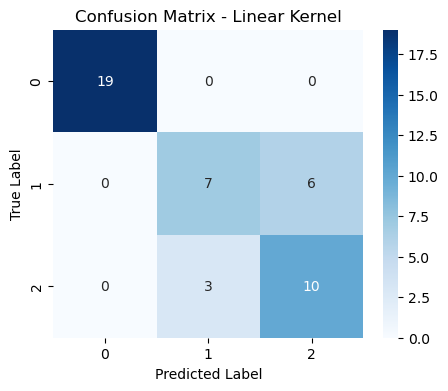

\n========================================
Training and Tuning for Polynomial Kernel...
Best Hyperparameters for Polynomial: {'C': 1000, 'degree': 3, 'gamma': 100, 'kernel': 'poly'}
\nClassification Report for Polynomial:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.75      0.46      0.57        13
           2       0.61      0.85      0.71        13

    accuracy                           0.80        45
   macro avg       0.79      0.77      0.76        45
weighted avg       0.82      0.80      0.79        45



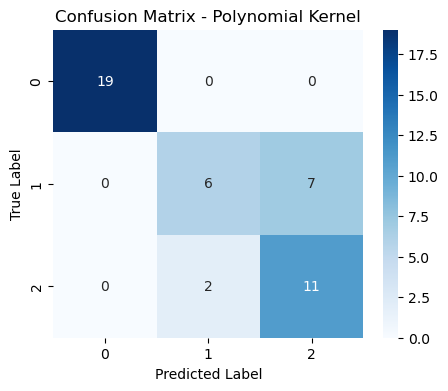

\n========================================
Training and Tuning for RBF Kernel...
Best Hyperparameters for RBF: {'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
\nClassification Report for RBF:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.54      0.54      0.54        13
           2       0.54      0.54      0.54        13

    accuracy                           0.73        45
   macro avg       0.69      0.69      0.69        45
weighted avg       0.73      0.73      0.73        45



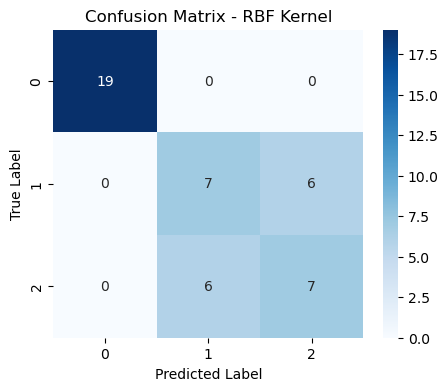

In [18]:
#############################################################################################################################
################################################## TO DO ####################################################################
#Split the dataset into training and test sets using train_test_split() from sklearn.model_selection.                       #
#Use a 70-30 split ratio.                                                                                                   #
#Normalize the dataset using StandardScaler from sklearn.preprocessing.                                                     #
#Define parameter grids for each kernel type (linear, poly, and rbf) for hyperparameter tuning.                             #
#Perform cross-validation for each kernel type.                                                                             #
#Report the best hyperparameters for each kernel type.                                                                      #
#Predict on the test set using each tuned model.                                                                            #
#Evaluate each model using confusion matrix, recall, precision, and F1 score. Use confusion_matrix and                      # 
#classification_report from sklearn.metrics.                                                                                #
#############################################################################################################################
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # to plot confusion matrix nicely


# 1. Split the dataset (70% training, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# 2. Normalize the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # we do not fit the scaler again on test data, we use the same scaler fitted on training data

# 3. Define parameter grids for each kernel
param_grid_linear = {
    'kernel': ['linear'],
    'C': [0.1, 1, 10, 100, 1000]
}

param_grid_poly = {
    'kernel': ['poly'],
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [0.001, 0.01, 0.1, 1, 10, 100],
    'degree': [2, 3] # polinom degree 
}

param_grid_rbf = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [0.001, 0.01, 0.1, 1, 10, 100]
}

# 4. Perform GridSearchCV and Evaluate for each kernel
grids = [param_grid_linear, param_grid_poly, param_grid_rbf]
kernel_names = ['Linear', 'Polynomial', 'RBF']

for param_grid, name in zip(grids, kernel_names):
    print(f"\\n{'='*40}")
    print(f"Training and Tuning for {name} Kernel...")
    print(f"{'='*40}")
    
    # perform GridSearchCV and train the model (cv=5 means 5-fold cross validation)
    grid_search = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
    
    # report the best parameters
    print(f"Best Hyperparameters for {name}: {grid_search.best_params_}")
    
    # predict on the test set using the best model
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    
    # report the metrics
    print(f"\\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix Visualization 
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name} Kernel')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


#############################################################################################################################
#                                                    END OF YOUR CODE                                                       #
#############################################################################################################################

Explanation: 

Based on the Classification Report, both the Linear and Polynomial (Degree 3) kernel models achieved the best overall performance with an accuracy of 80%. Both models perfectly classified Class 0 (100% precision and recall), but struggled to distinguish between Class 1 and Class 2. This makes sense because we are only using the first two features of the Iris dataset (Sepal Length and Sepal Width). In a 2D feature space, the data points of Class 1 and Class 2 heavily overlap, making perfect separation almost impossible.

Although RBF is generally a very powerful kernel, it performed the worst here with 73% accuracy. This is due to the hyperparameters selected by GridSearchCV (C: 1000, gamma: 0.001). A very low gamma value like 0.001 makes the sphere of influence of a single training example extremely large, causing the decision boundary to become too broad and rigid (underfitting). While trying to draw a generalized boundary, the model failed to capture the nuances between Class 1 and Class 2, essentially performing no better than random guessing for those two classes (F1-score: 0.54).

## Q3) CIFAR-10 with Non-linear SVM Exercise

In this question you are expected to train a multi class SVM model on **CIFAR-10** dataset. First, we will download and load the dataset, and visualize some random examples.

To obtain the dataset, you need to import **subprocess** module and run the following cell. By default, these commands will be executed in the current working directory where your Python script is located. 

In [19]:
import subprocess

# Download CIFAR-10 dataset
subprocess.run(["wget", "http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"])

# Extract CIFAR-10 dataset
subprocess.run(["tar", "-xzvf", "cifar-10-python.tar.gz"])

# Remove the downloaded tar.gz file
subprocess.run(["rm", "cifar-10-python.tar.gz"])

--2026-05-02 21:50:39--  http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz [following]
--2026-05-02 21:50:40--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 503 Service Unavailable
2026-05-02 21:50:40 ERROR 503: Service Unavailable.

tar: Error opening archive: Failed to open 'cifar-10-python.tar.gz'
rm: cifar-10-python.tar.gz: No such file or directory


CompletedProcess(args=['rm', 'cifar-10-python.tar.gz'], returncode=1)

CIFAR-10's samples are already splitted into a training and a test set by design. 

In [1]:
import pickle
import numpy as np
from data_utils import load_cifar10_data

# Example usage
data_dir = 'cifar-10-batches-py'  # Directory where the CIFAR-10 dataset files are located
X_train, y_train, X_test, y_test = load_cifar10_data(data_dir)

In [2]:
y_train.shape

(50000,)

In [3]:
# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 3072)
Training labels shape:  (50000,)
Test data shape:  (10000, 3072)
Test labels shape:  (10000,)


Now, we can visualize some images from the dataset. 

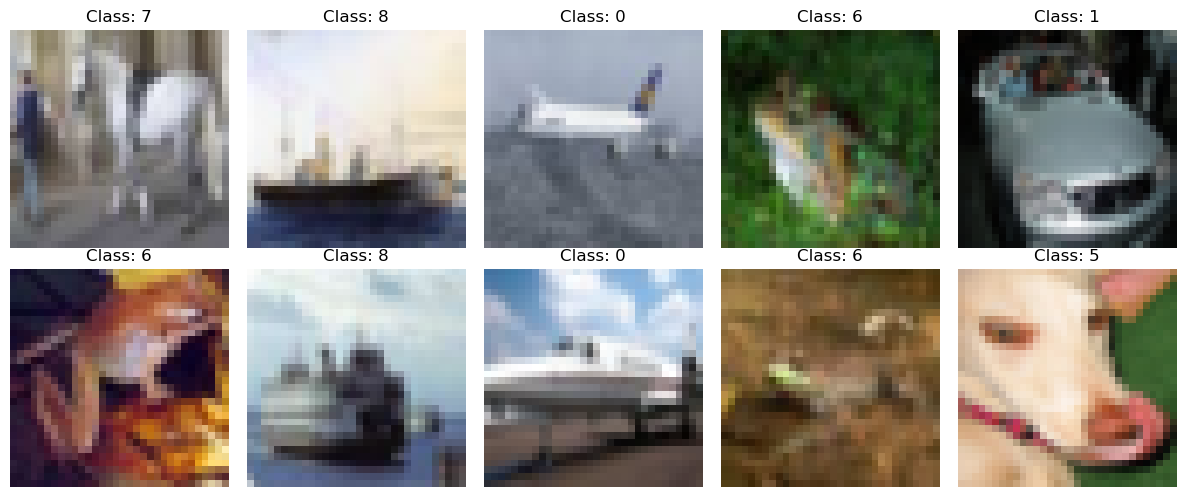

In [4]:
# Visualize examples from the dataset in random order
import numpy as np
import matplotlib.pyplot as plt

num_examples = 10  # Number of examples to visualize
indices = np.random.choice(len(X_train), num_examples, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0).astype('uint8'))
    plt.title(f'Class: {y_train[idx]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Training an SVC on this dataset may take a lot of time with a single CPU. Let's narrow down the dataset and apply dimensionality reduction to get a much more compact version of it. This way, a large amount of information will be lost, but the computation time will decrease. We will pick 1100 of images from each class for training, and 100 samples from each class for testing. Then, we will apply **Principal Component Analysis (PCA)**, a dimensionality reduction method. New dataset will have 400 features.

In [5]:
X_train_subset, y_train_subset, X_test_subset, y_test_subset = [], [], [], []

ones = [1100 for j in range(10)]

for x, y in zip(X_train, y_train):
    if ones[y] != 0:

        X_train_subset.append(x)
        y_train_subset.append(y)
        ones[y]-=1

print(np.asarray(X_train_subset).shape)

ones = [100 for j in range(10)]

for x, y in zip(X_test, y_test):
    if ones[y] != 0:

        X_test_subset.append(x)
        y_test_subset.append(y)
        ones[y]-=1

X_train_subset, y_train_subset, X_test_subset, y_test_subset = np.asarray(X_train_subset), np.asarray(y_train_subset), np.asarray(X_test_subset), np.asarray(y_test_subset)

(11000, 3072)


Next, we need to **vectorize** the images: 

In [6]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train_subset, (X_train_subset.shape[0], -1))
X_test = np.reshape(X_test_subset, (X_test_subset.shape[0], -1))
y_train = y_train_subset
y_test = y_test_subset
# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Test data shape: ', X_test.shape)

Training data shape:  (11000, 3072)
Test data shape:  (1000, 3072)


The next step is to normalize the dataset. And applying PCA to decrease the feature dimensions to 400. You are free to increase the dimension by tackling with **n_components** parameter. This will 

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca = PCA(n_components=400)

# Normalize the dataset
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pca.fit_transform(X_train_scaled)
X_test_scaled = pca.transform(X_test_scaled)

Later, You are assigned call an RBF kernel classifier.

You should use **cross validation** (you may use sklearn) and report the best hyperparameters $\gamma$ and $C$ you've found. You will use these hyperparameters for testing later. Once you have selected the best hyperparameters for each kernel, complete the following:

- Report Confusion matrix, Recall, Precision, and F1 Score.
- Visualize the learned weights for each class.
  
Suggested ranges for searching C and $\gamma$ parameters:

- C (Regularization parameter): [0.1, 1, 10, 100, 1000]. It's common to use a logarithmic scale for searching C values.

- $\gamma$ (Kernel coefficient for 'rbf' kernel): [0.001, 0.01, 0.1, 1, 10, 100] Since the dataset will be scaled, you can explore a broader range of gamma values.

Starting GridSearchCV for CIFAR-10 with RBF Kernel...
\nBest Hyperparameters (CIFAR-10): {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
\n(Classification Report):
              precision    recall  f1-score   support

           0       0.52      0.43      0.47       100
           1       0.56      0.61      0.59       100
           2       0.41      0.36      0.38       100
           3       0.29      0.34      0.31       100
           4       0.36      0.31      0.33       100
           5       0.41      0.35      0.38       100
           6       0.47      0.49      0.48       100
           7       0.56      0.48      0.52       100
           8       0.60      0.64      0.62       100
           9       0.46      0.61      0.52       100

    accuracy                           0.46      1000
   macro avg       0.46      0.46      0.46      1000
weighted avg       0.46      0.46      0.46      1000



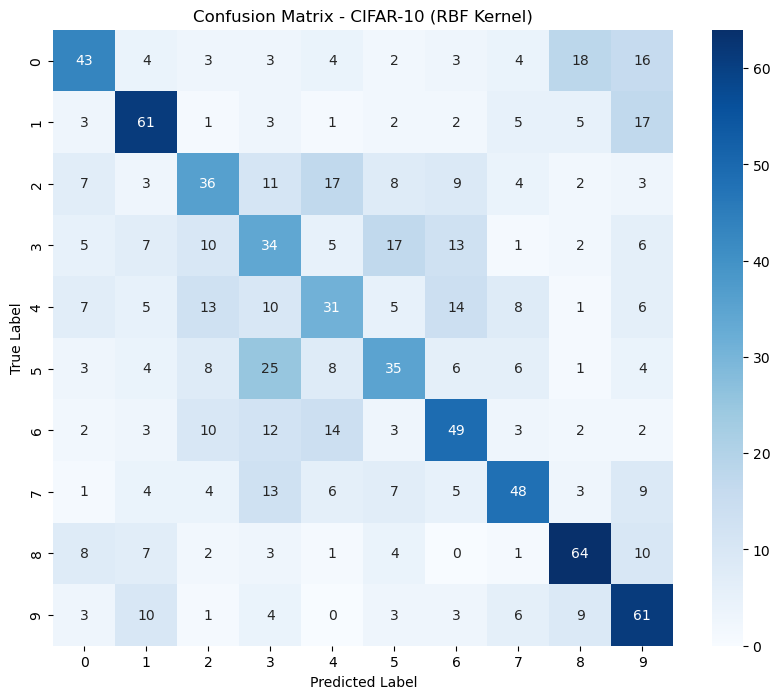

In [27]:
#############################################################################################################################
################################################## TO DO ####################################################################                                                                                      #
#Define parameter grids for RBF for hyperparameter tuning.                                                                  #
#Perform cross-validation.                                                                                                  #
#Report the best hyperparameters for each kernel type.                                                                      #
#Predict on the test set using each tuned model.                                                                            #
#Evaluate each model using confusion matrix, recall, precision, and F1 score. Use confusion_matrix and                      # 
#classification_report from sklearn.metrics.                                                                                #
#############################################################################################################################
print("Starting GridSearchCV for CIFAR-10 with RBF Kernel...")

# 1. define grid for RBF kernel
param_grid_cifar = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [0.001, 0.01, 0.1, 1, 10, 100]
}

# 2. do the grid search and fit the model (cv=3 means 3-fold cross validation)
grid_search_cifar = GridSearchCV(SVC(), param_grid_cifar, cv=3, n_jobs=-1)
grid_search_cifar.fit(X_train_scaled, y_train)

# 3. show the best parameters
print(f"\\nBest Hyperparameters (CIFAR-10): {grid_search_cifar.best_params_}")

# 4. predict on the test set using the best model
best_model_cifar = grid_search_cifar.best_estimator_
y_pred_cifar = best_model_cifar.predict(X_test_scaled)

# 5. report the results
print("\\n(Classification Report):")
print(classification_report(y_test, y_pred_cifar))

# 6. confusion matrix visualization
cm_cifar = confusion_matrix(y_test, y_pred_cifar)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cifar, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CIFAR-10 (RBF Kernel)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


#############################################################################################################################
#                                                    END OF YOUR CODE                                                       #
#############################################################################################################################


LINEAR KERNEL: WEIGHT VISUALIZATION (PCA FEATURES)


/Users/ahmedsaidgulsen/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/ahmedsaidgulsen/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



--- PERFORMANCE ---
Linear Kernel Accuracy: 0.2510

Weight matrix shape: (10, 400)
(10 classes x 400 PCA features)


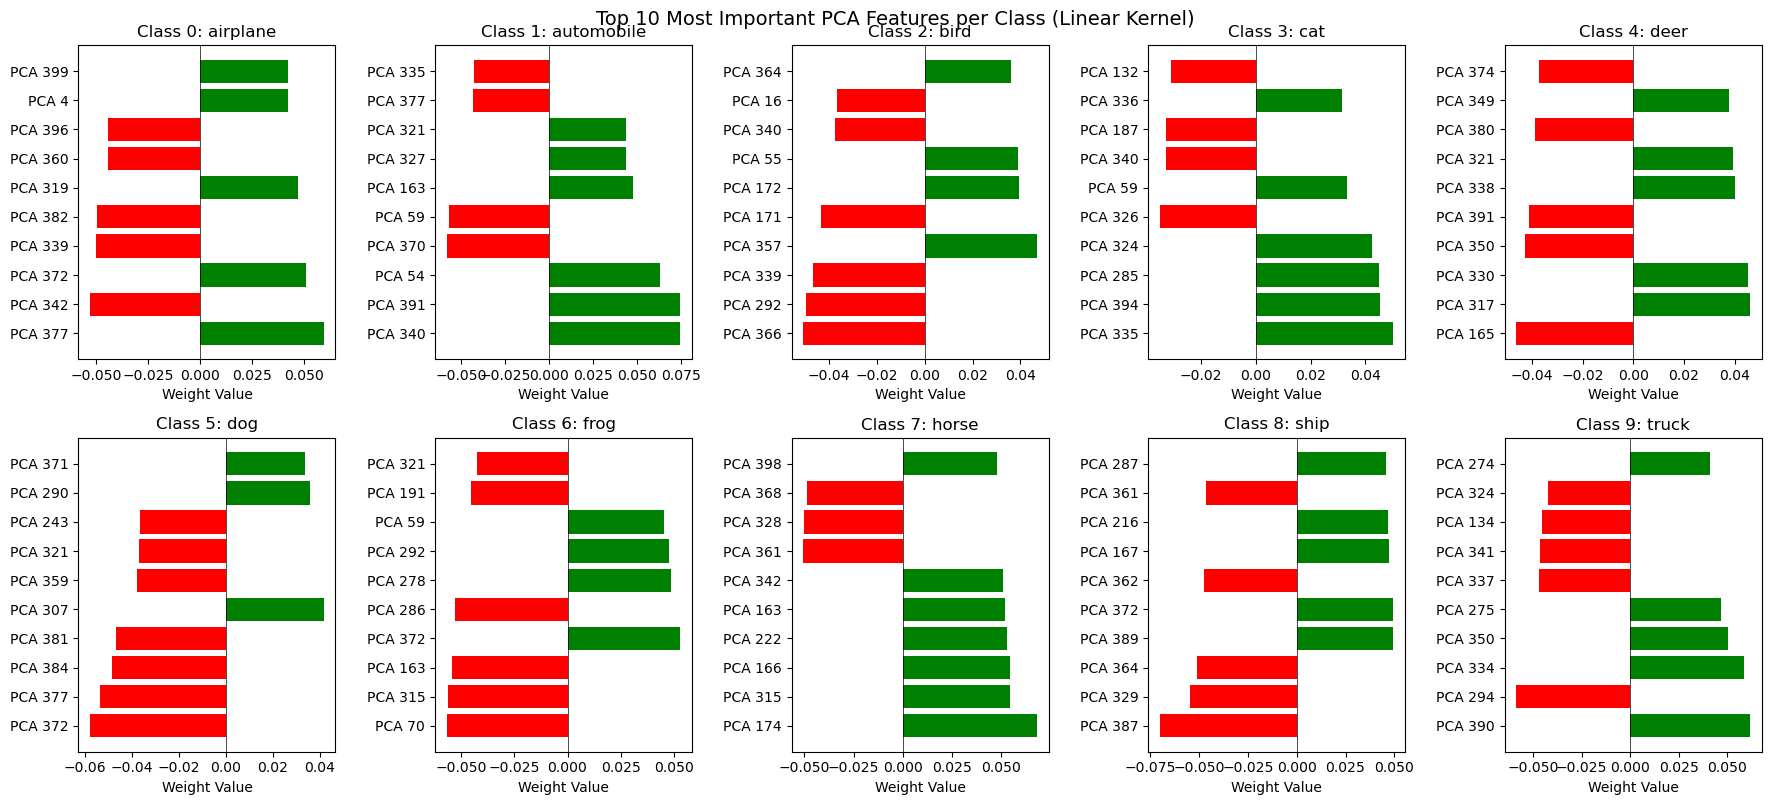

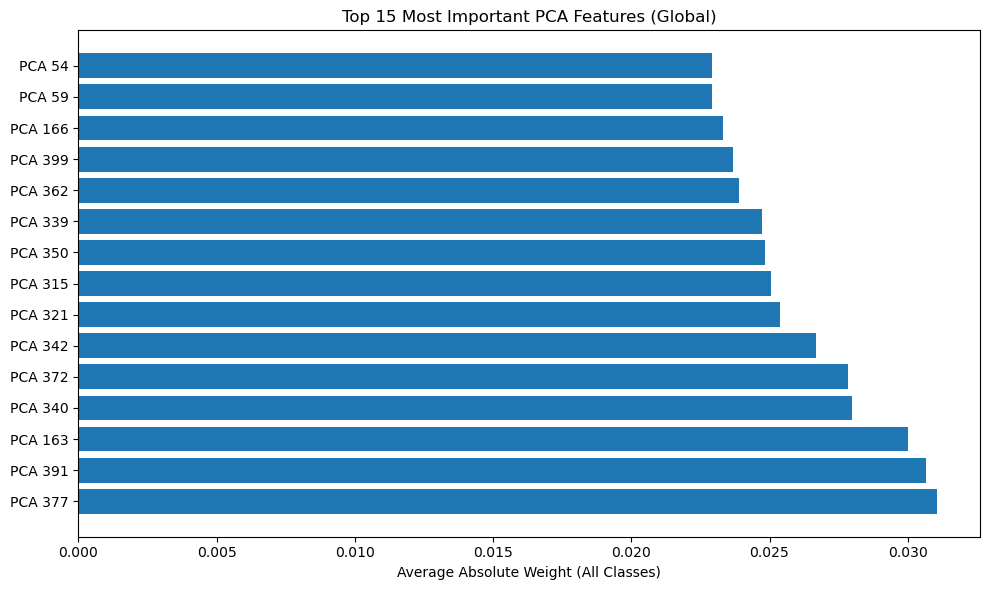


INTERPRETATION:

✓ Green bars = Positive weights (increases class probability)
✗ Red bars = Negative weights (decreases class probability)

- Ağırlıklar doğrudan dönüştürülmüş PCA bileşenlerinin (features) etkisini gösterir.
- Örneğin bir sınıf için yeşil ve uzun bir çubuk, o PCA bileşeninin o sınıfı tanımlamada çok kritik bir rol oynadığını belirtir.



In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

##############################################################################
# BONUS: Linear Kernel Weight Visualization & Interpretation                 #
##############################################################################
print("\n" + "="*70)
print("LINEAR KERNEL: WEIGHT VISUALIZATION (PCA FEATURES)")
print("="*70)

# 1. Hızlı LinearSVC modelini eğitiyoruz (C=1.0 soft margin)
linear_svm = LinearSVC(C=1.0, max_iter=1000) 
linear_svm.fit(X_train_scaled, y_train)

# 2. prediction and accuracy
y_pred_linear = linear_svm.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)

print("\n--- PERFORMANCE ---")
print(f"Linear Kernel Accuracy: {acc_linear:.4f}")
# Note: rbf accuracy was %46 

# 3. getting the weights: shape = (10 classes, 400 PCA features)
weights = linear_svm.coef_  

print(f"\nWeight matrix shape: {weights.shape}")
print(f"(10 classes x 400 PCA features)")

# 4. visualize the top 10 most important features for each class
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

for class_idx in range(10):
    ax = axes[class_idx]
    
    # top 10 features for this class based on absolute weight values
    top_indices = np.argsort(np.abs(weights[class_idx]))[-10:][::-1]
    top_weights = weights[class_idx][top_indices]
    
    colors = ['green' if w > 0 else 'red' for w in top_weights]
    ax.barh(range(len(top_indices)), top_weights, color=colors)
    ax.set_yticks(range(len(top_indices)))
    ax.set_yticklabels([f'PCA {i}' for i in top_indices])
    ax.set_xlabel('Weight Value')
    ax.set_title(f'Class {class_idx}: {class_names[class_idx]}')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.suptitle('Top 10 Most Important PCA Features per Class (Linear Kernel)', 
             fontsize=14, y=1.00)
plt.show()

# 5. global feature importance: average absolute weight across all classes
feature_magnitude = np.mean(np.abs(weights), axis=0)
top_global_features = np.argsort(feature_magnitude)[-15:][::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_global_features)), 
         feature_magnitude[top_global_features])
plt.yticks(range(len(top_global_features)), 
           [f'PCA {i}' for i in top_global_features])
plt.xlabel('Average Absolute Weight (All Classes)')
plt.title('Top 15 Most Important PCA Features (Global)')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print("""
✓ Green bars = Positive weights (increases class probability)
✗ Red bars = Negative weights (decreases class probability)

- Ağırlıklar doğrudan dönüştürülmüş PCA bileşenlerinin (features) etkisini gösterir.
- Örneğin bir sınıf için yeşil ve uzun bir çubuk, o PCA bileşeninin o sınıfı tanımlamada çok kritik bir rol oynadığını belirtir.
""")